In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv(r"data/processed/shopping_cleaned.csv")

print(df.shape)
print(df.head())
print(df.dtypes)

(3158, 13)
    Age Gender Item Purchased  Purchase Amount (USD)    Location Size  \
0  31.0   Male       Leggings              24.231704      Nevada    M   
1  38.0   Male     Sunglasses              36.545487      Oregon    S   
2  26.0   Male       Leggings              23.595139      Nevada   XL   
3  43.0   Male          Dress              34.079015  California    M   
4  29.0   Male         Shorts              23.796439   Minnesota    M   

         Color  Season Review Rating Shipping Type Promo Code Used  \
0  Terra cotta  Winter       Present      Standard              No   
1    Aubergine  Summer       Missing      Standard              No   
2        Brown  Winter       Missing      Standard              No   
3  Terra cotta    Fall       Present      Standard              No   
4     Lavender  Summer       Present       Express              No   

   Previous Purchases Payment Method  
0                   0    Credit Card  
1                   0    Credit Card  
2           

In [3]:
#Assignment Question 1:  What are the most popular colors by season?
color_by_season = df.groupby(['Season', 'Color']).size().reset_index(name='Count')
top_3_colors = color_by_season.sort_values(['Season', 'Count'], ascending=[True, False]).groupby('Season').head(3)

print(top_3_colors.to_string(index=False))

Season        Color  Count
  Fall        Brown     97
  Fall Burnt orange     93
  Fall  Terra cotta     91
Spring    Baby blue     69
Spring        White     63
Spring     Lavender     55
Summer     Lavender    102
Summer Lemon yellow     98
Summer    Baby blue     84
Winter        Black    124
Winter Burnt orange    112
Winter    Aubergine    111


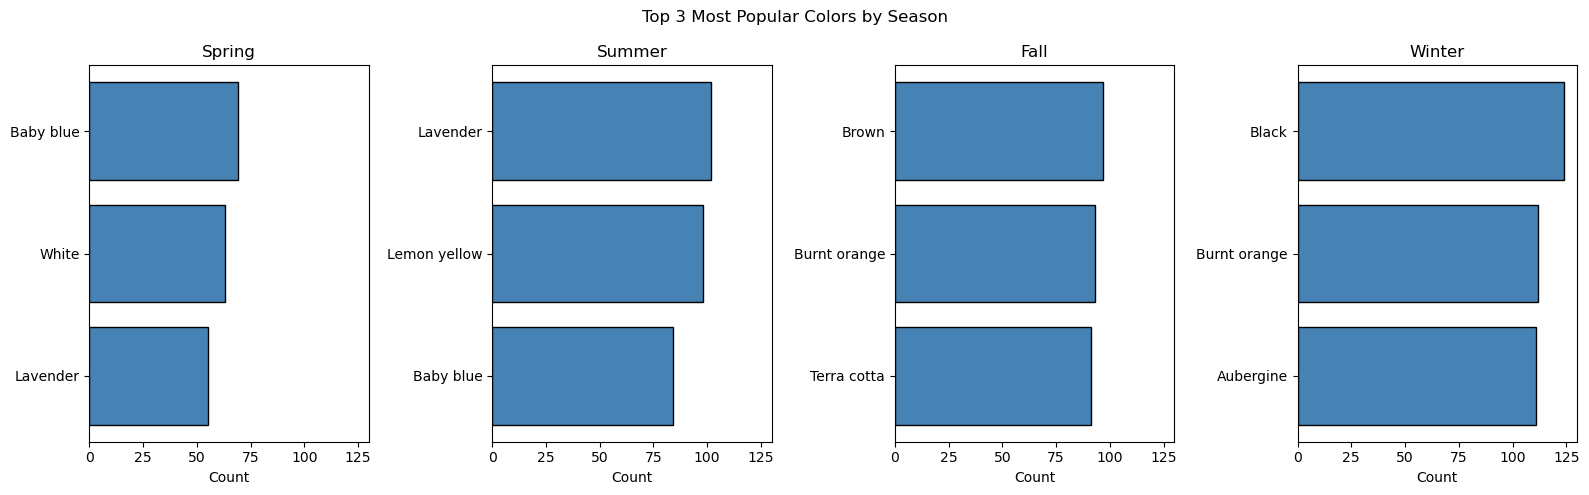

In [4]:
#Assignment question 2: Color by Season Chart
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, season in enumerate(season_order):
    season_data = top_3_colors[top_3_colors['Season'] == season].sort_values('Count')
    axes[i].barh(season_data['Color'], season_data['Count'], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{season}')
    axes[i].set_xlabel('Count')
    axes[i].set_xlim(0, 130) 

plt.suptitle('Top 3 Most Popular Colors by Season')
plt.tight_layout()
plt.show()

In [5]:
# Question 2: What is the most popular clothing item by season?
item_by_season = df.groupby(['Season', 'Item Purchased']).size().reset_index(name='Count')
top_3_items = item_by_season.sort_values(['Season', 'Count'], ascending=[True, False]).groupby('Season').head(3)

print(top_3_items.to_string(index=False))

Season Item Purchased  Count
  Fall       Backpack     72
  Fall        Sweater     72
  Fall          Socks     71
Spring  Running Shoes     89
Spring     Sunglasses     80
Spring        T-shirt     80
Summer         Shorts    152
Summer     Sunglasses    135
Summer  Running Shoes    134
Winter       Leggings    118
Winter       Backpack    113
Winter        Sweater    113


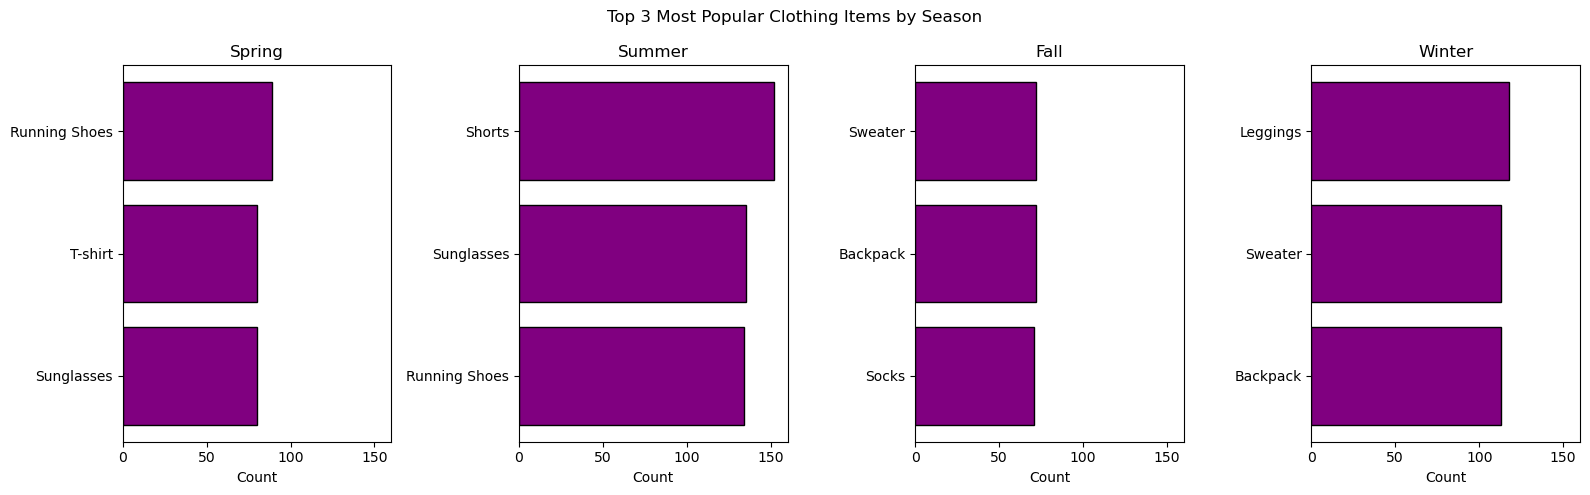

In [6]:
# Question 2 Chart: Most Popular Clothing Item by Season
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, season in enumerate(season_order):
    season_data = top_3_items[top_3_items['Season'] == season].sort_values('Count')
    axes[i].barh(season_data['Item Purchased'], season_data['Count'], color='purple', edgecolor='black')
    axes[i].set_title(f'{season}')
    axes[i].set_xlabel('Count')
    axes[i].set_xlim(0, 160)

plt.suptitle('Top 3 Most Popular Clothing Items by Season')
plt.tight_layout()
plt.show()

In [7]:
# Assignemnt Question 3: What is the effect of promo codes on purchase amounts?
promo_effect = df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean().reset_index()
promo_effect.columns = ['Promo Code Used', 'Average Purchase (USD)']

print(promo_effect.to_string(index=False))

Promo Code Used  Average Purchase (USD)
             No               30.155751
            Yes               50.067480


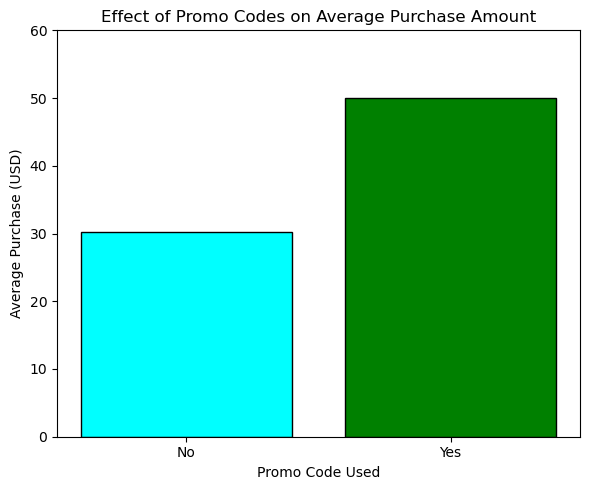

In [8]:
# Question 3 Chart: Effect of Promo Codes on Purchase Amount
fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(promo_effect['Promo Code Used'], promo_effect['Average Purchase (USD)'],
       color=['aqua', 'green'], edgecolor='black')
ax.set_title('Effect of Promo Codes on Average Purchase Amount')
ax.set_xlabel('Promo Code Used')
ax.set_ylabel('Average Purchase (USD)')
ax.set_ylim(0,60)

plt.tight_layout()
plt.show()

In [9]:
# Assignment Question 4: When do users leave a review?
review_counts = df.groupby('Review Rating').size().reset_index(name='Count')

print(review_counts.to_string(index=False))

Review Rating  Count
      Missing   2020
      Present   1138


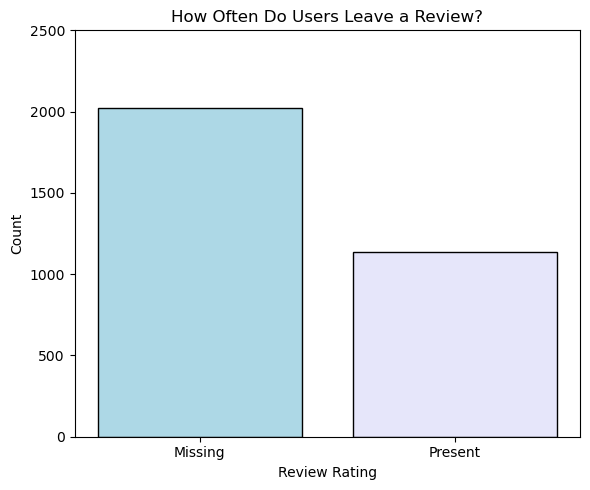

In [10]:
# Question 4 Chart: When do users leave a review?
fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(review_counts['Review Rating'], review_counts['Count'],
       color=['lightblue', 'lavender'], edgecolor='black')
ax.set_title('How Often Do Users Leave a Review?')
ax.set_xlabel('Review Rating')
ax.set_ylabel('Count')
ax.set_ylim(0, 2500)

plt.tight_layout()
plt.show()

## Findings
**Question 1: Most Popular Colors by Season**
- Fall favors warm earth tones: Brown (97), Burnt Orange (93), Terra Cotta (91)
- Spring favors cool/light colors: Baby Blue (69), White (63), Lavender (55)
- Summer favors bright colors: Lavendar (102), Lemon Yellow(98), Baby Blue (84)
- Winter favors dark/bold colors: Black(124), Burnt Orange (112), Aubergine (111)

**Question 2: Most Popular Clothing Items by Season**
- Fall: Backpack & Sweater tied at (72), Socks (71)
- Spring: Running Shoes (89), Sunglasses & T-shirt tied (80)
-  Summer: Shorts (152), Sunglasses (135), Running Shoes (134)
- Winter: Leggings (118), Backpack & Sweater tied (113)

** Question 3: Effect of Promo Codes on Purchase Amount**
- Customers without promo codes spent an average of $30.16
- Customers with promo codes spent an average of $50.07
- Promo codes are associated with a $19.91 increase in spending

** Question 4: When Do Users Leave a Review**
- Only 1,138 out of 3,158 customers left a review (36%)
- 2,020 customers did not leave a reivew (64%)

In [12]:
# Question 1: How does average purchase amount vary across age groups?
df['Age Group'] = pd.cut(df['Age'], bins=[0,20,30,40,50,60,100], 
                          labels=['<20','20s','30s','40s','50s','60+'])
avg_by_age = df.groupby('Age Group')['Purchase Amount (USD)'].mean().reset_index()
print(avg_by_age.to_string(index=False))

Age Group  Purchase Amount (USD)
      <20              38.882764
      20s              38.615431
      30s              38.972618
      40s              38.518954
      50s              39.762547
      60+              38.837618


Purchase amounts are remarkably consistent across age groups, all clustering tightly between $38.52–$39.76
50s spent the most on average ($39.76), <20 spent second-most ($38.88) — but the spread across all groups is under $1.25, suggesting age has little to no meaningful effect on spending amount

In [13]:
# Question 2: Which seasons show highest total purchase volume, by item category?
season_volume = df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
print(season_volume)

season_item_volume = df.groupby(['Season','Item Purchased'])['Purchase Amount (USD)'].sum().reset_index()
top_item_per_season = season_item_volume.sort_values(['Season','Purchase Amount (USD)'], ascending=[True,False]).groupby('Season').head(1)
print(top_item_per_season.to_string(index=False))

Season
Winter    40168.104540
Fall      33953.962697
Summer    29642.915700
Spring    18805.682195
Name: Purchase Amount (USD), dtype: float64
Season Item Purchased  Purchase Amount (USD)
  Fall       Backpack            2850.862560
Spring  Running Shoes            3575.810211
Summer         Shorts            5887.897332
Winter       Leggings            4614.956953


Winter drives the highest total revenue ($40,168), followed by Fall ($33,954), Summer ($29,643), and Spring ($18,806) — over double Spring's volume
Top-grossing item per season: Winter → Leggings ($4,615), Summer → Shorts ($5,888, the single highest of any season/item combo), Fall → Backpack ($2,851), Spring → Running Shoes ($3,576)

In [14]:
# Question 3: Promo code use vs. spending (duplicates Required Question 3 — same result)
promo_spending = df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()
print(promo_spending)

Promo Code Used
No     30.155751
Yes    50.067480
Name: Purchase Amount (USD), dtype: float64


Matches the required-questions finding: promo code users spent $50.07 on average vs. $30.16 for non-users — a $19.91 difference

In [15]:
# Question 4: Which demographic group has highest purchase frequency? (using Previous Purchases as proxy)
freq_by_gender = df.groupby('Gender')['Previous Purchases'].mean()
freq_by_age = df.groupby('Age Group')['Previous Purchases'].mean()
print(freq_by_gender)
print(freq_by_age)

Gender
Female        5.777419
Male          5.901837
Non-binary    8.103448
Name: Previous Purchases, dtype: float64
Age Group
<20    6.513514
20s    5.821773
30s    6.020349
40s    5.565517
50s    5.373134
60+    5.375000
Name: Previous Purchases, dtype: float64


By gender: Non-binary customers had the highest average previous purchases (8.10), notably above Male (5.90) and Female (5.78)
By age group: customers under 20 had the highest average previous purchases (6.51), with a general downward trend as age increases (50s and 60+ lowest, ~5.37–5.38)

In [16]:
# Question 5: Are certain payment methods associated with higher-value transactions?
payment_avg = df.groupby('Payment Method')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
print(payment_avg)

Payment Method
Bank Transfer    43.340929
Debit Card       39.033523
PayPal           38.840409
Venmo            38.740305
Credit Card      38.605994
Cash             36.549009
Name: Purchase Amount (USD), dtype: float64


Bank Transfer users had the highest average purchase amount ($43.34), notably above all other methods
Cash transactions were lowest on average ($36.55); the remaining methods (Debit Card, PayPal, Venmo, Credit Card) clustered closely together (~$38.61–$39.03)

In [17]:
# Question 6: Which states generate highest revenue, and how does it correlate with previous purchases?
state_revenue = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
state_prev_purchases = df.groupby('Location')['Previous Purchases'].mean()
state_combined = pd.DataFrame({'Total Revenue': state_revenue, 'Avg Previous Purchases': state_prev_purchases}).sort_values('Total Revenue', ascending=False)
print(state_combined.head(10))

                Total Revenue  Avg Previous Purchases
Location                                             
California        3115.704856                6.548780
Nebraska          2836.962269                6.250000
Delaware          2802.469847                4.680556
Montana           2795.195079                6.438356
West Virginia     2789.993478                5.328571
Indiana           2772.996540                6.190476
South Carolina    2764.657100                5.676471
Illinois          2743.014968                7.095890
Minnesota         2684.441101                4.985915
Louisiana         2672.225865                5.000000


California led in total revenue ($3,115.70), followed by Nebraska, Delaware, and Montana
No clear correlation between a state's total revenue and its customers' average previous-purchase count — e.g., Illinois had the lowest revenue in the top 10 ($2,743) but the highest avg. previous purchases (7.10), while Delaware had strong revenue ($2,802) but the lowest avg. previous purchases (4.68) in the group